## 바이오 빅데이터 분석 (4B)
### ANN 회귀 실습: Gene expression + mutation + Morgan fingerprint 기반 CCLE-CTRPv2 AUC 예측

이번 실습에서는 세포주(cell line)의 유전자 발현량과 mutation 정보, 그리고 compound의 Morgan fingerprint를 함께 사용하여 특정 cell line-compound 조합의 AUC를 예측합니다.

기존 2B 회귀 실습은 하나의 compound를 정해두고 `gene expression -> AUC`를 예측했습니다. 이번 실습에서는 AUC matrix를 long-form table로 바꾸어, 한 행이 하나의 `(cell line, compound)` 조합을 나타내도록 확장합니다.

#### 학습 목표

- CCLE-CTRPv2의 gene expression, mutation, drug response, compound SMILES 정보를 함께 다룬다.
- compound의 protein target gene을 이용해 target-gene mutation matrix를 만든다.
- compound SMILES에서 Morgan fingerprint를 계산한다.
- cell line-level feature와 compound-level feature를 결합한 supervised learning table을 만든다.
- LASSO, RandomForest, ANN regressor를 같은 test set에서 비교한다.
- ANN의 validation split, early stopping, trainable parameter 수를 이해한다.


### 0. 실습 환경

필요 패키지는 `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `rdkit`, `tensorflow`입니다.

`rdkit`은 Morgan fingerprint 계산에 필요하고, `tensorflow`는 ANN 모델 학습에 필요합니다. 설치가 되어 있지 않은 환경에서는 아래 설치 셀을 참고하세요.


In [ ]:
# 필요할 때만 실행하세요.
# conda 환경에서는 다음을 권장합니다.
# !conda install -c conda-forge rdkit tensorflow -y

# pip 환경에서는 다음을 사용할 수 있습니다.
# !pip install rdkit tensorflow


In [ ]:
from pathlib import Path
import importlib.util
import random
import warnings

import numpy as np
import pandas as pd

# pandas 3.x + 일부 pyarrow 조합에서 read_csv string inference 문제가 생길 수 있습니다.
pd.set_option("future.infer_string", False)

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from sklearn import metrics as met
from sklearn import model_selection as mod_sel
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [ ]:
# Morgan fingerprint 계산을 위한 RDKit 확인
if importlib.util.find_spec("rdkit") is None:
    raise ImportError("rdkit이 필요합니다. 위 설치 셀을 참고하여 rdkit을 설치한 뒤 커널을 재시작하세요.")

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem

RDLogger.DisableLog("rdApp.warning")
RDLogger.DisableLog("rdApp.error")

# ANN 학습을 위한 TensorFlow/Keras 확인
# TensorFlow가 없어도 데이터 전처리와 기존 ML 파트는 실행할 수 있게 optional로 둡니다.
TF_AVAILABLE = importlib.util.find_spec("tensorflow") is not None

if TF_AVAILABLE:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    tf.random.set_seed(RANDOM_STATE)
    print("TensorFlow version:", tf.__version__)
else:
    print("TensorFlow is not installed. ANN section requires tensorflow.")


## 1. 실습 개요와 문제 정의, 데이터 불러오기

이번 실습의 예측 문제는 다음과 같습니다.

```text
cell line feature + compound feature -> AUC(cell line, compound)
```

- cell line feature: gene expression + target-gene mutation
- compound feature: Morgan fingerprint from SMILES
- label: CTRPv2 AUC

QM9 데이터 자체를 이번 예측 문제에 직접 사용하지는 않습니다. 다만 5A 실습에서 배운 Morgan fingerprint 계산 방법을 CTRPv2 compound의 SMILES에 적용합니다.


### 1-1. CCLE-CTRPv2 데이터 불러오기

로컬 폴더의 `data_CCLE_CTRPv2/*.csv` 파일을 우선 사용합니다. 로컬 CSV가 없고 `mlbi-lab`이 설치된 환경이라면 fallback으로 `load_data('ccle-ctrpv2')`를 사용할 수 있습니다.


In [ ]:
def find_data_dir():
    """Return the local folder that contains CCLE-CTRPv2 CSV files."""
    # 노트북을 Work_BioBigdata_KOTHEA 안에서 실행하는 경우와 상위 폴더에서 실행하는 경우를 모두 고려합니다.
    candidates = [
        Path("data_CCLE_CTRPv2"),
        Path("Work_BioBigdata_KOTHEA/data_CCLE_CTRPv2"),
    ]
    # 실제로 존재하는 첫 번째 폴더를 사용합니다.
    for candidate in candidates:
        if candidate.exists():
            return candidate
    # 폴더가 아직 없더라도 아래 load 함수에서 명확한 에러를 내도록 기본 후보를 반환합니다.
    return candidates[0]


def load_ccle_ctrpv2(base_dir=None):
    """Load CCLE-CTRPv2 tables from local CSV files or mlbi-lab fallback."""
    # base_dir을 직접 주지 않으면 현재 실행 위치에 맞는 데이터 폴더를 찾습니다.
    base = Path(base_dir) if base_dir is not None else find_data_dir()
    # 실습에서 사용할 6개 CSV 파일 경로를 한 곳에 정리합니다.
    files = {
        "gene_expression": base / "ccle_ctrpv2_gene_exp.csv",
        "cellline_info": base / "ccle_ctrpv2_cellline_info.csv",
        "auc": base / "ccle_ctrpv2_auc.csv",
        "ec50": base / "ccle_ctrpv2_ec50.csv",
        "drug_info": base / "ccle_ctrpv2_drug_info.csv",
        "mutation_info": base / "ccle_ctrpv2_mutation_info.csv",
    }

    # 모든 CSV가 있으면 로컬 파일을 바로 읽습니다.
    if all(path.exists() for path in files.values()):
        print("Loading local CSV files from", base.resolve())
        # 첫 번째 열은 sample/drug id이므로 index_col=0으로 index로 사용합니다.
        return {key: pd.read_csv(path, index_col=0) for key, path in files.items()}

    # 로컬 파일이 없을 때만 mlbi-lab 데이터 로더를 시도합니다.
    try:
        from mlbi.data import load_data
        print("Local CSV files were not found. Loading data with mlbi-lab fallback.")
        return load_data("ccle-ctrpv2")
    except Exception as exc:
        # 둘 다 실패하면 학생이 확인할 수 있는 메시지를 보여줍니다.
        raise FileNotFoundError(
            "Local CSV files were not found and mlbi-lab fallback failed. "
            "Check data_CCLE_CTRPv2/ or install mlbi-lab."
        ) from exc


# 데이터 전체를 dictionary 형태로 불러옵니다.
data = load_ccle_ctrpv2()
data.keys()


In [ ]:
df_gexp = data["gene_expression"]
df_cl_info = data["cellline_info"]
df_auc = data["auc"]
df_ec50 = data["ec50"]
df_drug_info = data["drug_info"]
df_mutation_info = data["mutation_info"]

print("gene expression:", df_gexp.shape)
print("cell line info :", df_cl_info.shape)
print("AUC            :", df_auc.shape)
print("EC50           :", df_ec50.shape)
print("drug info      :", df_drug_info.shape)
print("mutation info  :", df_mutation_info.shape)


In [ ]:
display(df_gexp.iloc[:5, :8])
display(df_auc.iloc[:5, :8])
display(df_drug_info[["cpd_name", "cpd_smiles", "gene_symbol_of_protein_target"]].head())
display(df_mutation_info.head())


## 2. 데이터 전처리

### 데이터 전처리 전체 흐름

이번 실습에서는 세포주 정보와 화합물 정보를 함께 사용하여 AUC를 예측합니다.

1. 전체 compound의 protein target gene을 모읍니다.
2. 해당 target gene들의 mutation feature matrix를 만듭니다.
   - 행: cell line
   - 열: `mut_<gene>_any`, `mut_<gene>_damaging`, `mut_<gene>_hotspot`
3. gene expression matrix에 mutation matrix를 붙여 cell line-level feature matrix를 만듭니다.
4. AUC matrix를 long-form table로 변환합니다.
   - 기존: cell line x compound matrix
   - 변환 후: 한 행이 하나의 `(cell line, compound, AUC)` 조합
5. 각 row에 해당 cell line feature와 compound Morgan fingerprint를 붙입니다.


### 2-1. 사용할 compound와 cell line 선택

AUC 값이 있고, `drug_info`에 SMILES가 있는 compound만 사용합니다. Morgan fingerprint를 계산하려면 `cpd_smiles`가 필요합니다.

실습 노트북이 너무 무거워지지 않도록 기본값은 AUC sample 수가 많은 compound 80개만 사용합니다. 전체 compound를 사용하려면 아래 코드에서 `MAX_COMPOUNDS = None`으로 바꾸면 됩니다.


In [ ]:
# Step 0. AUC matrix와 drug_info 양쪽에 존재하며 SMILES가 있는 compound를 선택합니다.
common_compounds = df_auc.columns.intersection(df_drug_info.index)
smiles_mask = df_drug_info.loc[common_compounds, "cpd_smiles"].notna()
usable_compounds = df_drug_info.loc[common_compounds].loc[smiles_mask].index.tolist()

# 너무 작은 실습 환경에서는 일부 compound만 사용해 빠르게 실행할 수 있습니다.
# 전체 compound를 사용하려면 MAX_COMPOUNDS = None 으로 둡니다.
MAX_COMPOUNDS = 80
if MAX_COMPOUNDS is not None:
    compound_counts = df_auc[usable_compounds].notna().sum().sort_values(ascending=False)
    usable_compounds = compound_counts.head(MAX_COMPOUNDS).index.tolist()

usable_cell_lines = df_gexp.index.intersection(df_auc.index).tolist()

print("Usable cell lines:", len(usable_cell_lines))
print("Usable compounds :", len(usable_compounds))
print("Observed AUC pairs:", int(df_auc.loc[usable_cell_lines, usable_compounds].notna().sum().sum()))

display(df_drug_info.loc[usable_compounds, ["cpd_name", "gene_symbol_of_protein_target", "cpd_smiles"]].head())


### 2-2. compound별 protein target gene 정리

이 단계에서는 mutation feature로 사용할 gene 목록을 정합니다. 모든 유전자의 mutation을 쓰는 대신, CTRPv2 compound의 protein target gene만 선택합니다.


In [ ]:
def parse_target_gene_string(value):
    """Parse a semicolon-separated target-gene string into a clean gene list."""
    # target gene 정보가 비어 있으면 빈 list를 반환합니다.
    if pd.isna(value):
        return []
    # CTRPv2 target gene column은 EGFR;ERBB2 처럼 semicolon으로 여러 gene이 들어갈 수 있습니다.
    return [gene.strip() for gene in str(value).split(";") if gene.strip()]


# compound마다 protein target gene list를 저장합니다.
compound_target_genes = {
    compound: parse_target_gene_string(df_drug_info.loc[compound, "gene_symbol_of_protein_target"])
    for compound in usable_compounds
}

# Step 1. 전체 compound에서 protein target gene 목록을 모읍니다.
all_target_genes = sorted({
    gene
    for genes in compound_target_genes.values()
    for gene in genes
})

# expression matrix와 mutation table에 실제로 존재하는 target gene만 따로 확인합니다.
target_genes_in_expression = [gene for gene in all_target_genes if gene in df_gexp.columns]
target_genes_in_mutation = [gene for gene in all_target_genes if gene in set(df_mutation_info["Hugo_Symbol"])]

print("Protein target genes from usable compounds:", len(all_target_genes))
print("Target genes in expression matrix       :", len(target_genes_in_expression))
print("Target genes in mutation table          :", len(target_genes_in_mutation))
print(target_genes_in_mutation[:30])


In [ ]:
target_summary = (
    pd.Series({compound: ";".join(genes) for compound, genes in compound_target_genes.items()}, name="target_genes")
    .to_frame()
    .join(df_auc[usable_compounds].notna().sum().rename("n_AUC_samples"))
    .join(df_drug_info[["cpd_name", "target_or_activity_of_compound"]])
    .sort_values("n_AUC_samples", ascending=False)
)

display(target_summary.head(20))


### 2-3. mutation 정보로 target-gene mutation matrix 만들기

mutation table은 long-format입니다. 이를 `cell line x mutation feature` matrix로 바꾸어 gene expression matrix와 병합할 수 있게 만듭니다.


In [ ]:
def as_boolean(series):
    """Convert mixed boolean-like values such as True, 1, yes into bool values."""
    # 결측값은 False로 보고, 문자열로 바꾼 뒤 소문자로 통일합니다.
    normalized = series.fillna(False).astype(str).str.lower()
    # 데이터에 따라 True/1/yes처럼 저장된 값을 모두 True로 처리합니다.
    return normalized.isin(["true", "1", "yes"])


def make_target_mutation_matrix(mutation_info, target_genes, sample_index):
    """Build a cell line x target-gene mutation feature matrix."""
    # mutation table에 실제로 등장하는 target gene만 사용합니다.
    target_genes = [gene for gene in target_genes if gene in set(mutation_info["Hugo_Symbol"])]

    # 각 gene마다 any/damaging/hotspot 세 종류의 binary feature를 만듭니다.
    feature_columns = []
    for gene in target_genes:
        feature_columns.extend([
            f"mut_{gene}_any",
            f"mut_{gene}_damaging",
            f"mut_{gene}_hotspot",
        ])

    # 기본값은 모두 0입니다. mutation이 확인된 cell line만 아래에서 1로 바꿉니다.
    mutation_matrix = pd.DataFrame(0, index=sample_index, columns=feature_columns, dtype=np.int8)
    if not target_genes:
        return mutation_matrix

    # target gene mutation 중 실습에 사용할 cell line에 해당하는 행만 남깁니다.
    mut = mutation_info.loc[
        mutation_info["Hugo_Symbol"].isin(target_genes)
        & mutation_info["ccl_name"].isin(sample_index)
    ].copy()
    if mut.empty:
        return mutation_matrix

    # damaging mutation과 hotspot mutation 여부를 boolean feature로 정리합니다.
    mut["is_damaging_feature"] = as_boolean(mut["isDeleterious"])
    mut["is_hotspot_feature"] = as_boolean(mut["isTCGAhotspot"]) | as_boolean(mut["isCOSMIChotspot"])

    # gene별로 mutation이 있는 cell line을 찾아 해당 feature를 1로 표시합니다.
    for gene in target_genes:
        gene_mut = mut[mut["Hugo_Symbol"] == gene]
        if gene_mut.empty:
            continue

        # any는 해당 gene에 mutation record가 하나라도 있는 경우입니다.
        any_cells = gene_mut["ccl_name"].unique()
        # damaging은 isDeleterious가 True인 mutation이 있는 경우입니다.
        damaging_cells = gene_mut.loc[gene_mut["is_damaging_feature"], "ccl_name"].unique()
        # hotspot은 TCGA 또는 COSMIC hotspot annotation이 있는 경우입니다.
        hotspot_cells = gene_mut.loc[gene_mut["is_hotspot_feature"], "ccl_name"].unique()

        mutation_matrix.loc[mutation_matrix.index.isin(any_cells), f"mut_{gene}_any"] = 1
        mutation_matrix.loc[mutation_matrix.index.isin(damaging_cells), f"mut_{gene}_damaging"] = 1
        mutation_matrix.loc[mutation_matrix.index.isin(hotspot_cells), f"mut_{gene}_hotspot"] = 1

    return mutation_matrix


# Step 2. mutation long table을 cell line x mutation feature matrix로 변환합니다.
df_mut_features = make_target_mutation_matrix(
    df_mutation_info,
    target_genes_in_mutation,
    sample_index=usable_cell_lines,
)

print("Mutation feature matrix:", df_mut_features.shape)
display(df_mut_features.iloc[:5, :12])


In [ ]:
mutation_frequency = df_mut_features.sum(axis=0).sort_values(ascending=False)
display(mutation_frequency.head(20).to_frame("n_mutated_cell_lines"))


### 2-4. gene expression matrix 전처리

gene expression은 cell line-level feature입니다. 이후 같은 cell line의 mutation feature와 합쳐집니다.

실습 속도를 위해 기본값은 분산이 큰 유전자 500개만 사용합니다. 단, compound protein target gene의 expression은 빠지지 않도록 추가합니다.


In [ ]:
# Step 3-1. gene expression matrix를 전처리합니다.
df_log_gexp = np.log10(df_gexp.loc[usable_cell_lines] + 1)

TOP_N_GENES = 500
if TOP_N_GENES is None or TOP_N_GENES >= df_log_gexp.shape[1]:
    selected_expression_genes = df_log_gexp.columns.tolist()
else:
    selected_expression_genes = (
        df_log_gexp.var(axis=0)
        .sort_values(ascending=False)
        .head(TOP_N_GENES)
        .index
        .tolist()
    )

# target gene expression은 생물학적으로 중요할 수 있으므로 항상 포함합니다.
selected_expression_genes = sorted(set(selected_expression_genes).union(target_genes_in_expression))
df_expr_features = df_log_gexp.loc[:, selected_expression_genes].copy()
df_expr_features.columns = [f"expr_{gene}" for gene in df_expr_features.columns]

print("Expression feature matrix:", df_expr_features.shape)
display(df_expr_features.iloc[:5, :8])


### 2-5. gene expression matrix에 mutation matrix 붙이기

여기까지의 결과는 cell line 하나당 하나의 feature vector입니다. 아직 compound 정보는 포함되어 있지 않습니다.


In [ ]:
# Step 3-2. cell line-level feature: expression + mutation
cellline_features = pd.concat([df_expr_features, df_mut_features], axis=1).copy()

expr_cols = df_expr_features.columns.tolist()
mut_cols = df_mut_features.columns.tolist()

print("Expression features:", len(expr_cols))
print("Mutation features  :", len(mut_cols))
print("Cell line features :", cellline_features.shape)
display(cellline_features.iloc[:5, :10])


### 2-6. compound SMILES에서 Morgan fingerprint 만들기

Morgan fingerprint는 compound-level feature입니다. 이후 long-form AUC table의 compound 이름을 기준으로 각 row에 붙입니다.

이 함수는 5A QM9 실습에서 사용한 Morgan fingerprint 계산 방식과 같은 아이디어입니다. 실습 속도를 위해 기본 fingerprint 길이는 512 bit로 두었고, 더 정밀한 표현을 쓰려면 `MORGAN_BITS = 2048`로 바꿀 수 있습니다.


In [ ]:
def morgan_fingerprint_from_smiles(smiles, radius=2, n_bits=2048):
    """Convert one SMILES string into a Morgan fingerprint bit vector."""
    # SMILES 문자열을 RDKit molecule 객체로 변환합니다.
    mol = Chem.MolFromSmiles(str(smiles))
    # RDKit이 해석하지 못하는 SMILES는 None으로 표시해 나중에 제외합니다.
    if mol is None:
        return None
    # radius와 bit 수를 지정해 Morgan fingerprint bit vector를 계산합니다.
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    # RDKit vector를 numpy array로 옮길 빈 배열을 준비합니다.
    arr = np.zeros((n_bits,), dtype=np.float32)
    # RDKit fingerprint 값을 numpy array에 채웁니다.
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


# Step 4. compound SMILES를 compound x Morgan fingerprint matrix로 변환합니다.
MORGAN_RADIUS = 2
MORGAN_BITS = 512

fingerprint_rows = []
valid_fingerprint_compounds = []
invalid_compounds = []

for compound in usable_compounds:
    # 현재 compound의 SMILES를 가져옵니다.
    smiles = df_drug_info.loc[compound, "cpd_smiles"]
    # SMILES를 Morgan fingerprint vector로 변환합니다.
    arr = morgan_fingerprint_from_smiles(smiles, radius=MORGAN_RADIUS, n_bits=MORGAN_BITS)
    if arr is None:
        # fingerprint 계산에 실패한 compound는 기록만 해두고 제외합니다.
        invalid_compounds.append(compound)
    else:
        # 성공한 compound는 index와 vector를 나란히 저장합니다.
        valid_fingerprint_compounds.append(compound)
        fingerprint_rows.append(arr)

# fingerprint bit마다 column name을 붙입니다.
fp_cols = [f"fp_{i}" for i in range(MORGAN_BITS)]
# compound x fingerprint matrix를 DataFrame으로 만듭니다.
df_fp_features = pd.DataFrame(
    np.vstack(fingerprint_rows),
    index=valid_fingerprint_compounds,
    columns=fp_cols,
)

print("Morgan fingerprint matrix:", df_fp_features.shape)
print("Invalid SMILES compounds:", len(invalid_compounds))
display(df_fp_features.iloc[:5, :12])


### 2-7. AUC matrix를 long-form table로 변환하기

AUC matrix를 long-form으로 바꾸면 학습 샘플 수가 증가합니다. 각 row는 특정 cell line과 특정 compound의 반응값 하나를 의미합니다.


In [ ]:
# Step 5. AUC matrix를 long-form table로 변환합니다.
auc_long = (
    df_auc.loc[usable_cell_lines, valid_fingerprint_compounds]
    .rename_axis("cell_line")
    .reset_index()
    .melt(id_vars="cell_line", var_name="compound", value_name="AUC")
    .dropna(subset=["AUC"])
    .reset_index(drop=True)
)

auc_long["AUC"] = auc_long["AUC"].astype(float)

print("Long-form AUC table:", auc_long.shape)
display(auc_long.head())


In [ ]:
print("Unique cell lines in long table:", auc_long["cell_line"].nunique())
print("Unique compounds in long table :", auc_long["compound"].nunique())
print("AUC range:", (auc_long["AUC"].min(), auc_long["AUC"].max()))

plt.figure(figsize=(6, 4))
sns.histplot(auc_long["AUC"], bins=40, color="steelblue")
plt.xlabel("AUC")
plt.title("Distribution of CTRPv2 AUC values")
plt.tight_layout()


### 2-8. long-form table에 cell line feature와 compound feature 병합하기

마지막으로 cell line-level feature와 compound-level feature를 같은 row에 붙입니다. 이 결과가 machine learning과 ANN에 들어갈 최종 supervised learning table입니다.


In [ ]:
# Step 6. long-form table에 cell line feature와 compound fingerprint를 병합합니다.
model_df = (
    auc_long
    .join(cellline_features, on="cell_line")
    .join(df_fp_features, on="compound")
)

# 병합 후 결측이 생긴 행은 제거합니다.
model_df = model_df.dropna().reset_index(drop=True)

all_feature_cols = expr_cols + mut_cols + fp_cols

print("Final modeling table:", model_df.shape)
print("Number of features  :", len(all_feature_cols))
display(model_df[["cell_line", "compound", "AUC"]].head())


In [ ]:
feature_count_summary = pd.DataFrame({
    "feature_group": ["expression", "mutation", "Morgan fingerprint", "all"],
    "n_features": [len(expr_cols), len(mut_cols), len(fp_cols), len(all_feature_cols)],
})
feature_count_summary


## 3. Train/test split과 feature set 구성

ANN과 기존 machine learning 모델을 공정하게 비교하기 위해 처음 분리한 test set은 모든 모델의 최종 평가에만 사용합니다.

- LASSO: train set 내부 GridSearchCV로 alpha 선택 후 test set 평가
- RandomForest: 정해진 parameter로 학습 후 test set 평가
- ANN: train set 내부 validation split으로 early stopping 후 test set 평가

주의: test set을 ANN validation으로 사용하면 early stopping 시점이 test set에 맞춰져 test 성능이 낙관적으로 보일 수 있습니다.


In [ ]:
train_df, test_df = mod_sel.train_test_split(
    model_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("Train rows:", train_df.shape[0])
print("Test rows :", test_df.shape[0])
print("Train compounds:", train_df["compound"].nunique())
print("Test compounds :", test_df["compound"].nunique())
print("Train cell lines:", train_df["cell_line"].nunique())
print("Test cell lines :", test_df["cell_line"].nunique())


In [ ]:
feature_sets = {
    "Model 1: expression only": expr_cols,
    "Model 2: expression + mutation": expr_cols + mut_cols,
    "Model 3: expression + fingerprint": expr_cols + fp_cols,
    "Model 4: expression + mutation + fingerprint": expr_cols + mut_cols + fp_cols,
}

feature_set_summary = pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "n_features": [len(cols) for cols in feature_sets.values()],
})
feature_set_summary


## 4. 기존 machine learning regression model

이번 섹션에서는 같은 train/test split에서 feature set별 성능을 비교합니다.

- LASSO: `ElasticNet(l1_ratio=1.0)`로 구현합니다. alpha 값만 train set 내부 GridSearchCV로 선택합니다.
- RandomForest: 비선형 기존 ML baseline으로 사용합니다.


### 4-1. 평가 함수 정의


In [ ]:
def regression_scores(y_true, y_pred):
    """Calculate common regression metrics for observed and predicted AUC."""
    # pandas Series가 들어와도 numpy array로 통일합니다.
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # correlation은 값의 분산이 있을 때만 계산할 수 있습니다.
    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        pcc = pearsonr(y_true, y_pred)[0]
        scc = spearmanr(y_true, y_pred)[0]
    else:
        pcc = np.nan
        scc = np.nan

    # 여러 metric을 dictionary로 반환하면 결과표를 만들기 쉽습니다.
    return {
        "PCC": pcc,
        "SCC": scc,
        "R2": met.r2_score(y_true, y_pred),
        "MAE": met.mean_absolute_error(y_true, y_pred),
        "RMSE": met.root_mean_squared_error(y_true, y_pred),
    }


def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs predicted"):
    """Draw a scatter plot comparing actual AUC and predicted AUC."""
    # plot title에 함께 표시할 성능 지표를 계산합니다.
    scores = regression_scores(y_true, y_pred)
    # y=x 기준선을 그리기 위해 실제값과 예측값의 전체 범위를 구합니다.
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))

    # 점 하나는 test set의 cell line-compound pair 하나입니다.
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.45, s=18)
    # 빨간 점선에 가까울수록 예측이 실제값과 비슷합니다.
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    plt.xlabel("Actual AUC")
    plt.ylabel("Predicted AUC")
    plt.title(f"{title}\nPCC={scores['PCC']:.3f}, R2={scores['R2']:.3f}, RMSE={scores['RMSE']:.3f}")
    plt.tight_layout()


### 4-2. LASSO alpha grid search와 RandomForest 학습

전체 long-form table은 행 수가 많기 때문에, LASSO alpha 탐색과 RandomForest 학습을 전체 train set에서 그대로 수행하면 시간이 오래 걸릴 수 있습니다.

여기서는 실습 속도를 위해 다음처럼 처리합니다.

- LASSO alpha 탐색: train set 중 최대 3,000 row를 사용하고 3-fold CV 수행
- LASSO 최종 학습과 RandomForest 학습: train set 중 최대 12,000 row 사용
- 최종 평가는 동일한 test set에서 수행

더 정확한 비교가 필요하면 `MAX_LASSO_TUNING_ROWS`와 `MAX_ML_TRAIN_ROWS`를 늘리면 됩니다.


In [ ]:
y_train = train_df["AUC"].astype(float)
y_test = test_df["AUC"].astype(float)

# Alpha 후보를 4개만 사용해 regularization 강도를 빠르게 비교합니다.
alpha_grid = {
    "model__alpha": [1e-4, 3e-4, 1e-3, 3e-3]
}

# GridSearchCV를 전체 train set에 바로 적용하면 오래 걸릴 수 있으므로,
# alpha 선택에는 train set 일부만 사용합니다.
MAX_LASSO_TUNING_ROWS = 3000
if len(train_df) > MAX_LASSO_TUNING_ROWS:
    lasso_tune_df = train_df.sample(MAX_LASSO_TUNING_ROWS, random_state=RANDOM_STATE)
else:
    lasso_tune_df = train_df.copy()

# 기존 ML 모델 학습도 실습 시간 안에 끝나도록 train set 일부만 사용합니다.
MAX_ML_TRAIN_ROWS = 12000
if len(train_df) > MAX_ML_TRAIN_ROWS:
    ml_fit_df = train_df.sample(MAX_ML_TRAIN_ROWS, random_state=RANDOM_STATE + 1)
else:
    ml_fit_df = train_df.copy()

print("Rows used for LASSO alpha tuning:", lasso_tune_df.shape[0])
print("Rows used for ML model fitting :", ml_fit_df.shape[0])
print("Rows used for final test       :", test_df.shape[0])

ml_results = []
ml_predictions = {}

for feature_set_name, cols in feature_sets.items():
    print("\nTraining models for", feature_set_name)
    X_train = ml_fit_df[cols]
    y_train_fit = ml_fit_df["AUC"].astype(float)
    X_test = test_df[cols]
    X_tune = lasso_tune_df[cols]
    y_tune = lasso_tune_df["AUC"].astype(float)

    # LASSO는 ElasticNet에서 l1_ratio=1.0인 경우입니다.
    lasso_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            l1_ratio=1.0,
            max_iter=2000,
            tol=1e-3,
            selection="random",
            random_state=RANDOM_STATE,
        )),
    ])

    # alpha는 train subset 안에서만 선택합니다. test set은 여기서 사용하지 않습니다.
    lasso_grid = mod_sel.GridSearchCV(
        estimator=lasso_pipeline,
        param_grid=alpha_grid,
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1,
    )
    lasso_grid.fit(X_tune, y_tune)
    best_alpha = lasso_grid.best_params_["model__alpha"]
    print("  LASSO best alpha:", best_alpha)

    # 선택된 alpha로 전체 train set에 최종 LASSO 모델을 학습합니다.
    best_lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=best_alpha,
            l1_ratio=1.0,
            max_iter=2000,
            tol=1e-3,
            selection="random",
            random_state=RANDOM_STATE,
        )),
    ])
    best_lasso.fit(X_train, y_train_fit)
    lasso_pred = best_lasso.predict(X_test)

    row = regression_scores(y_test, lasso_pred)
    row.update({
        "model": "LASSO",
        "feature_set": feature_set_name,
        "n_features": len(cols),
        "best_alpha": best_alpha,
    })
    ml_results.append(row)
    ml_predictions[("LASSO", feature_set_name)] = lasso_pred

    # RandomForest는 실습 속도를 위해 작게 설정합니다.
    rf_model = RandomForestRegressor(
        n_estimators=30,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_model.fit(X_train, y_train_fit)
    rf_pred = rf_model.predict(X_test)

    row = regression_scores(y_test, rf_pred)
    row.update({
        "model": "RandomForest",
        "feature_set": feature_set_name,
        "n_features": len(cols),
        "best_alpha": np.nan,
    })
    ml_results.append(row)
    ml_predictions[("RandomForest", feature_set_name)] = rf_pred

ml_result_df = pd.DataFrame(ml_results).sort_values(["RMSE", "MAE"])
ml_result_df

In [ ]:
# 표에는 RMSE, MAE, R2도 함께 표시되므로, 그림에서는 PCC만 간결하게 비교합니다.
plt.figure(figsize=(10, 4))
sns.barplot(
    data=ml_result_df,
    x="feature_set",
    y="PCC",
    hue="model",
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Test PCC (higher is better)")
plt.xlabel("")
plt.axhline(0, color="black", linewidth=1)
plt.title("Machine learning baseline comparison on the same test set")
plt.tight_layout()


### 4-2-1. True AUC와 predicted AUC 산점도

성능표와 barplot만 보면 모델이 어떤 방식으로 틀리는지 보기 어렵습니다. 아래 산점도는 test set에서 실제 AUC와 예측 AUC를 직접 비교합니다. 빨간 점선에 가까울수록 좋은 예측입니다.


In [ ]:
# PCC가 높은 상위 모델 몇 개를 산점도로 확인합니다.
models_to_plot = (
    ml_result_df
    .sort_values("PCC", ascending=False)
    .head(4)[["model", "feature_set"]]
    .itertuples(index=False, name=None)
)

models_to_plot = list(models_to_plot)
fig, axes = plt.subplots(1, len(models_to_plot), figsize=(4 * len(models_to_plot), 4), sharex=True, sharey=True)
if len(models_to_plot) == 1:
    axes = [axes]

for ax, (model_name, feature_set_name) in zip(axes, models_to_plot):
    y_pred = ml_predictions[(model_name, feature_set_name)]
    scores = regression_scores(y_test, y_pred)
    lo = min(y_test.min(), np.min(y_pred))
    hi = max(y_test.max(), np.max(y_pred))

    ax.scatter(y_test, y_pred, alpha=0.35, s=12)
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)

    short_feature_name = feature_set_name.replace("Model ", "M")
    title_text = (
        f"{model_name}\n"
        f"{short_feature_name}\n"
        f"PCC={scores['PCC']:.3f}, RMSE={scores['RMSE']:.3f}"
    )
    ax.set_title(title_text, fontsize=10)
    ax.set_xlabel("True AUC")
    ax.set_ylabel("Predicted AUC")

plt.tight_layout()


### 4-3. LASSO coefficient 확인

LASSO는 일부 coefficient를 0으로 만들기 때문에 feature selection 효과를 관찰할 수 있습니다. 아래 셀도 시간을 줄이기 위해 alpha 탐색은 train subset에서 수행하고, 선택된 alpha로 전체 train set에 다시 학습합니다.


In [ ]:
all_feature_name = "Model 4: expression + mutation + fingerprint"
all_cols = feature_sets[all_feature_name]

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        l1_ratio=1.0,
        max_iter=2000,
        tol=1e-3,
        selection="random",
        random_state=RANDOM_STATE,
    )),
])

lasso_grid = mod_sel.GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=alpha_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
)
lasso_grid.fit(lasso_tune_df[all_cols], lasso_tune_df["AUC"].astype(float))
best_alpha = lasso_grid.best_params_["model__alpha"]

best_lasso_for_coef = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=best_alpha,
        l1_ratio=1.0,
        max_iter=2000,
        tol=1e-3,
        selection="random",
        random_state=RANDOM_STATE,
    )),
])
best_lasso_for_coef.fit(ml_fit_df[all_cols], ml_fit_df["AUC"].astype(float))

coef = best_lasso_for_coef.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": all_cols,
    "coef": coef,
    "abs_coef": np.abs(coef),
}).sort_values("abs_coef", ascending=False)

print("Best alpha:", best_alpha)
print("Non-zero coefficients:", int((coef_df["coef"] != 0).sum()), "/", len(coef_df))
display(coef_df.head(20))


## 5. Artificial Neural Network regression model

ANN은 모든 feature를 사용한 `Model 5: ANN with all features`로 학습합니다. TensorFlow/Keras를 사용해 tabular regression용 MLP를 만듭니다.

ANN은 과적합이 쉽게 발생할 수 있으므로 train set 안에서 validation set을 따로 분리하고, validation loss가 좋아지지 않으면 early stopping으로 학습을 멈춥니다.


### 5-1. ANN train/validation split과 scaling


In [ ]:
if not TF_AVAILABLE:
    raise ImportError(
        "ANN 섹션을 실행하려면 tensorflow가 필요합니다. "
        "위 설치 셀을 참고하여 tensorflow를 설치한 뒤 커널을 재시작하세요."
    )

ann_feature_cols = feature_sets["Model 4: expression + mutation + fingerprint"]

ann_train_df, ann_val_df = mod_sel.train_test_split(
    train_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

X_ann_train_raw = ann_train_df[ann_feature_cols]
y_ann_train = ann_train_df["AUC"].astype(np.float32).to_numpy()

X_ann_val_raw = ann_val_df[ann_feature_cols]
y_ann_val = ann_val_df["AUC"].astype(np.float32).to_numpy()

X_ann_test_raw = test_df[ann_feature_cols]
y_ann_test = test_df["AUC"].astype(np.float32).to_numpy()

ann_scaler = StandardScaler()
X_ann_train = ann_scaler.fit_transform(X_ann_train_raw).astype(np.float32)
X_ann_val = ann_scaler.transform(X_ann_val_raw).astype(np.float32)
X_ann_test = ann_scaler.transform(X_ann_test_raw).astype(np.float32)

print("ANN train:", X_ann_train.shape)
print("ANN val  :", X_ann_val.shape)
print("ANN test :", X_ann_test.shape)


### 5-2. 쉽게 수정 가능한 MLP build 함수

아래 함수의 `hidden_units`, `activation`, `dropout_rate`, `learning_rate`를 바꾸면 ANN 구조와 학습 조건을 쉽게 조정할 수 있습니다.


#### 인공신경망 (ANN) 모형

<div style="display:flex; gap:24px; align-items:flex-start;">
  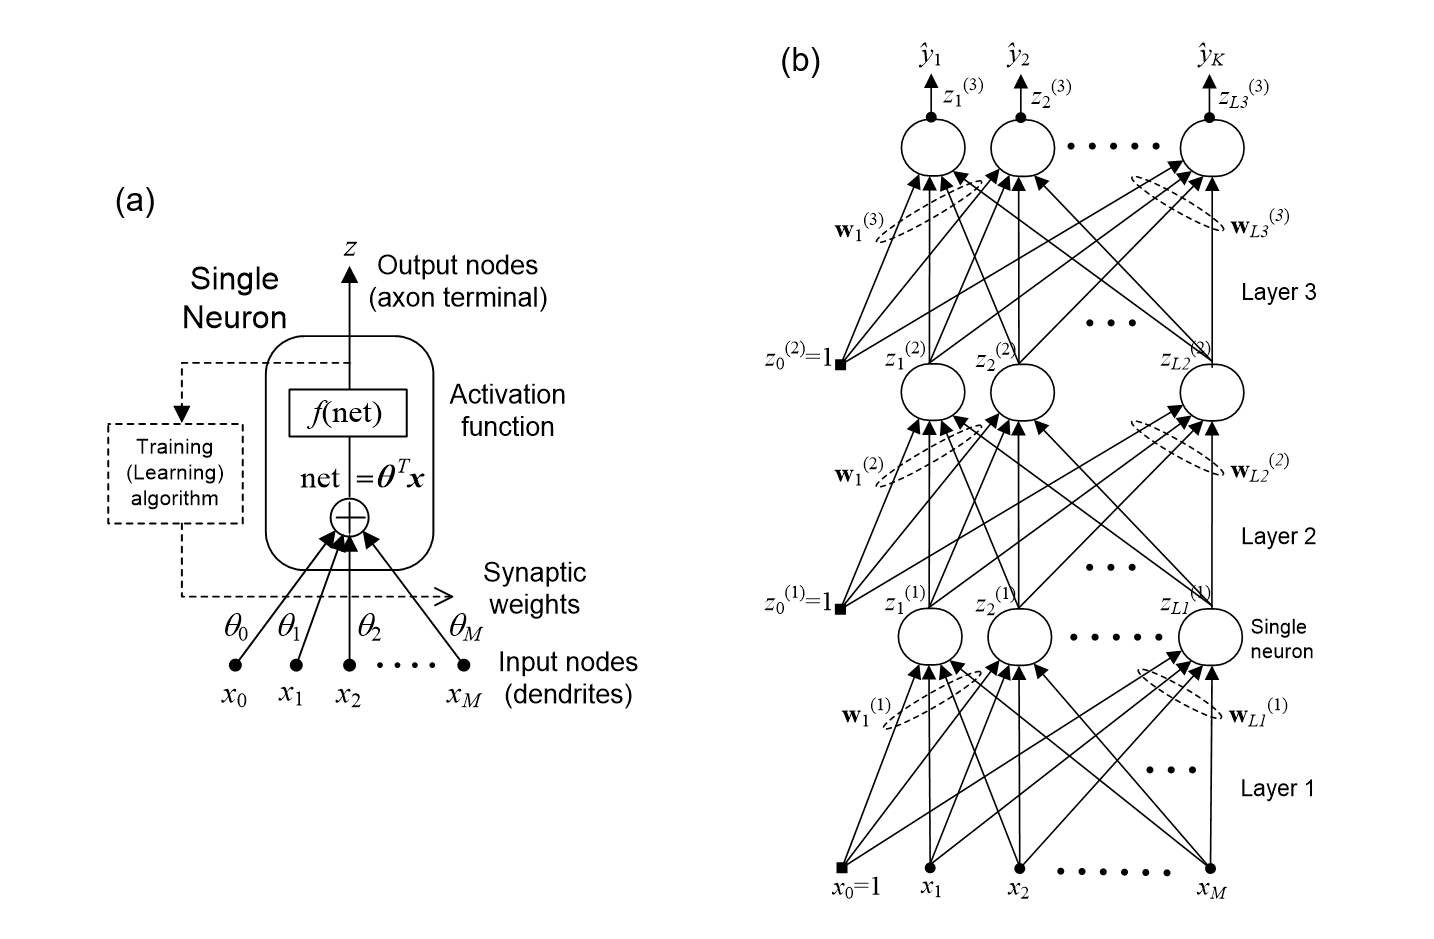  
</div>


In [ ]:
def build_mlp_regressor(
    n_features,
    hidden_units=(256, 128),
    activation="relu",
    dropout_rate=0.2,
    learning_rate=0.001,
):
    """Build and compile a Keras MLP regressor for AUC prediction."""
    # Sequential model은 layer를 위에서 아래로 순서대로 쌓는 가장 쉬운 방식입니다.
    model = keras.Sequential(name="mlp_auc_regressor")
    # 입력 layer의 길이는 최종 feature 개수와 같습니다.
    model.add(layers.Input(shape=(n_features,), name="input_features"))

    # hidden_units에 적은 숫자만큼 Dense hidden layer를 반복해서 추가합니다.
    for i, units in enumerate(hidden_units, start=1):
        # Dense layer는 모든 입력 feature와 neuron이 연결되는 fully connected layer입니다.
        model.add(layers.Dense(units, activation=activation, name=f"dense_{i}"))
        # Dropout은 학습 중 일부 neuron 출력을 꺼서 과적합을 줄이는 방법입니다.
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f"dropout_{i}"))

    # 회귀 문제이므로 마지막 출력은 activation 없는 숫자 1개입니다.
    model.add(layers.Dense(1, activation="linear", name="auc_output"))

    # optimizer, loss, metric을 지정해 학습 가능한 모델로 compile합니다.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )
    return model


### 5-3. ANN 모델 생성과 trainable parameter 수 확인

입력 feature 수와 hidden layer의 neuron 수가 늘어나면 trainable parameter 수도 증가합니다. parameter 수가 많아지면 표현력은 커질 수 있지만, 과적합 위험도 함께 커집니다.


In [ ]:
ann_model = build_mlp_regressor(
    n_features=X_ann_train.shape[1],
    hidden_units=(256, 128),
    activation="relu",
    dropout_rate=0.2,
    learning_rate=0.001,
)

ann_model.summary()


In [ ]:
def count_model_parameters(model):
    """Count trainable and non-trainable parameters in a Keras model."""
    # 학습으로 업데이트되는 weight/bias parameter 수를 계산합니다.
    trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    # BatchNorm처럼 학습으로 직접 업데이트되지 않는 parameter가 있으면 따로 계산합니다.
    non_trainable_params = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    # 결과를 Series/DataFrame으로 보기 쉽게 dictionary로 반환합니다.
    return {
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "total_params": trainable_params + non_trainable_params,
    }

pd.Series(count_model_parameters(ann_model))


### 5-4. Early stopping을 이용한 ANN 학습

Keras의 기본 progress bar는 한 줄이 길게 출력될 수 있습니다. 여기서는 `verbose=0`으로 기본 progress bar를 끄고, epoch마다 train/validation 성능을 짧은 한 줄로 출력하는 callback을 사용합니다.


In [ ]:
class CompactTrainingLogger(keras.callbacks.Callback):
    """Print compact train/validation metrics at the end of each epoch."""

    def __init__(self, total_epochs):
        # 최대 epoch 수를 저장해 출력에 함께 표시합니다.
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        # Keras가 전달한 metric dictionary를 안전하게 받습니다.
        logs = logs or {}
        # 화면에 길게 표시되는 progress bar 대신 필요한 metric만 짧게 출력합니다.
        msg = (
            f"Epoch {epoch + 1:03d}/{self.total_epochs} | "
            f"loss {logs.get('loss', float('nan')):.4f} | "
            f"mae {logs.get('mae', float('nan')):.4f} | "
            f"val_loss {logs.get('val_loss', float('nan')):.4f} | "
            f"val_mae {logs.get('val_mae', float('nan')):.4f}"
        )
        print(msg)


MAX_EPOCHS = 100

# EarlyStopping은 validation loss가 더 좋아지지 않을 때 학습을 멈춥니다.
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",        # validation MSE loss를 기준으로 관찰합니다.
    patience=10,               # 10 epoch 동안 개선이 없으면 멈춥니다.
    restore_best_weights=True, # 가장 validation 성능이 좋았던 epoch의 weight로 되돌립니다.
)

# 기본 Keras progress bar는 길게 출력되므로 verbose=0으로 끕니다.
# CompactTrainingLogger가 epoch마다 짧은 train/validation 성능을 대신 출력합니다.
history = ann_model.fit(
    X_ann_train,                         # ANN 학습 입력 feature
    y_ann_train,                         # ANN 학습 label, AUC
    validation_data=(X_ann_val, y_ann_val), # early stopping에 사용할 validation data
    epochs=MAX_EPOCHS,                   # 최대 epoch 수. early stopping이 더 일찍 멈출 수 있습니다.
    batch_size=128,                      # 한 번 weight update에 사용할 sample 수
    callbacks=[early_stop, CompactTrainingLogger(MAX_EPOCHS)],
    verbose=0,                           # 긴 progress bar를 숨깁니다.
)


In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("ANN learning curve")
plt.legend()
plt.tight_layout()


### 5-5. ANN test set 평가


In [ ]:
ann_test_pred = ann_model.predict(X_ann_test).ravel()
ann_scores = regression_scores(y_ann_test, ann_test_pred)

ann_result = {
    "model": "ANN",
    "feature_set": "Model 5: ANN with all features",
    "n_features": len(ann_feature_cols),
    "best_alpha": np.nan,
    **ann_scores,
    **count_model_parameters(ann_model),
}

pd.Series(ann_result)


In [ ]:
plot_actual_vs_predicted(y_ann_test, ann_test_pred, title="ANN with all features")


## 6. 전체 모델 성능 비교

마지막으로 모든 모델을 동일한 test set에서 비교합니다. LASSO와 RandomForest는 feature set 4종을 비교하고, ANN은 all features를 사용한 Model 5로 추가합니다.


In [ ]:
all_results_df = pd.concat(
    [
        ml_result_df,
        pd.DataFrame([ann_result]),
    ],
    ignore_index=True,
).sort_values("RMSE")

all_results_df[["model", "feature_set", "n_features", "PCC", "SCC", "R2", "MAE", "RMSE", "best_alpha"]]


In [ ]:
# 표에는 RMSE, MAE, R2도 함께 표시되므로, 그림에서는 PCC만 간결하게 비교합니다.
plt.figure(figsize=(11, 4))
sns.barplot(
    data=all_results_df,
    x="feature_set",
    y="PCC",
    hue="model",
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Test PCC (higher is better)")
plt.xlabel("")
plt.axhline(0, color="black", linewidth=1)
plt.title("Final model comparison on the same test set")
plt.tight_layout()


In [ ]:
best_row = all_results_df.iloc[0]
print("Best model:", best_row["model"])
print("Best feature set:", best_row["feature_set"])
print("Test RMSE:", best_row["RMSE"])
print("Test PCC:", best_row["PCC"])


## 7. 해석과 토의

다음 질문을 중심으로 결과를 해석해 봅시다.

참고: RMSE는 낮을수록 좋은 지표이고 PCC는 높을수록 좋은 지표입니다. fingerprint feature를 추가했을 때 RMSE가 낮아지거나 PCC가 높아지면 compound 구조 정보가 예측에 도움이 된 것으로 해석할 수 있습니다.

1. `expression only`, `expression + mutation`, `expression + fingerprint`, `all features` 중 어떤 feature set이 가장 좋은 성능을 보였나요?
2. mutation feature를 추가했을 때 성능이 항상 좋아졌나요? 그렇지 않다면 이유는 무엇일까요?
3. Morgan fingerprint를 추가하면 compound 간 차이를 모델이 학습할 수 있습니다. 실제 성능에서도 그 효과가 보이나요?
4. LASSO의 non-zero coefficient에는 어떤 feature가 많이 포함되었나요? expression, mutation, fingerprint 중 어느 쪽인가요?
5. ANN은 기존 ML 모델보다 좋은 성능을 보였나요? parameter 수와 과적합 가능성을 함께 고려하면 어떻게 해석할 수 있을까요?
6. 이번 실습의 random pair split에서는 train에서 본 cell line과 compound가 test에도 다시 등장할 수 있습니다. 새로운 compound에 대한 예측 성능을 보려면 어떤 split이 필요할까요?


### 선택 실습: split strategy 바꿔보기

이번 노트북에서는 실습을 단순하게 하기 위해 random pair split을 사용했습니다. 연구 질문에 따라 다음 split을 추가로 실험할 수 있습니다.

- cell-line split: test set에 새로운 cell line이 등장
- compound split: test set에 새로운 compound가 등장
- both unseen split: 새로운 cell line과 새로운 compound 조합을 예측

split 방식이 바뀌면 예측 문제가 훨씬 어려워질 수 있습니다. 따라서 drug response prediction에서는 모델 구조만큼이나 평가 전략이 중요합니다.
